# Deep Learning — Projeto Final
> Previsão de cancelamento de reservas hoteleiras com redes neuronais

**Curso:** Pós-graduação em Data Science e Business Intelligence  
**Disciplina:** Deep Learning | **Aluno:** Ricardo Filipe Fernandes da Silva


## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

from src.config        import TARGET, CATEGORICAL_COLS, NUMERIC_COLS, DEFAULT_DATA_PATH
from src.data          import load_data, reconstruct_booking_date
from src.preprocessing import clean_data, split_data, prepare_splits
from src.eda           import plot_missing, plot_target, plot_numeric, plot_categorical
from src.models        import (build_fnn_baseline, build_fnn_dropout,
                                build_cnn_baseline, build_cnn_regularized)
from src.train         import train_model, train_model_no_early_stop
from src.evaluate      import (evaluate_model, plot_history,
                                plot_confusion_matrix, compare_models, reshape_for_cnn)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


## 2. Problema e Objetivo

**Problema:** prever, no momento da reserva, se uma reserva hoteleira será cancelada.  
**Tipo:** classificação binária com dados tabulares.  
**Target:** `is_canceled` (0 = não cancelado · 1 = cancelado)  
**Métrica:** accuracy + F1-score por classe na avaliação final.

Serão comparadas duas abordagens:
- **FNN** (dense layers) — baseline, mais natural para dados tabulares
- **CNN** (Conv1D) — para avaliar se convolution layers acrescentam valor preditivo em dados tabulares


## 3. Dataset e EDA

In [2]:
df = load_data(DEFAULT_DATA_PATH)
display(df.head(3))


Dataset carregado: 119,390 observações, 32 colunas.


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


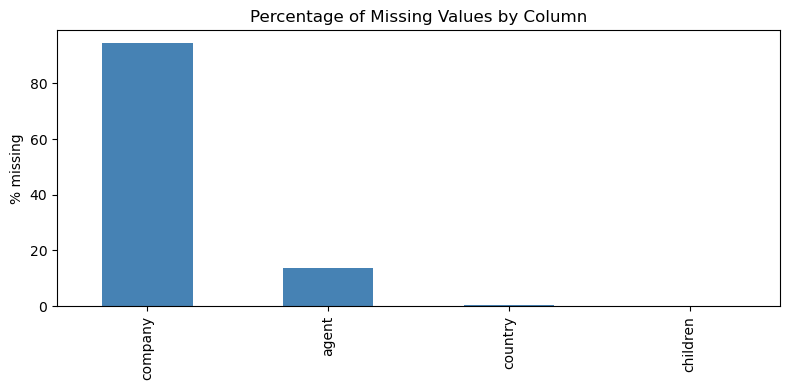

Distribuição (contagem):
 is_canceled
0    75166
1    44224
Name: count, dtype: int64

Distribuição (%):
 is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


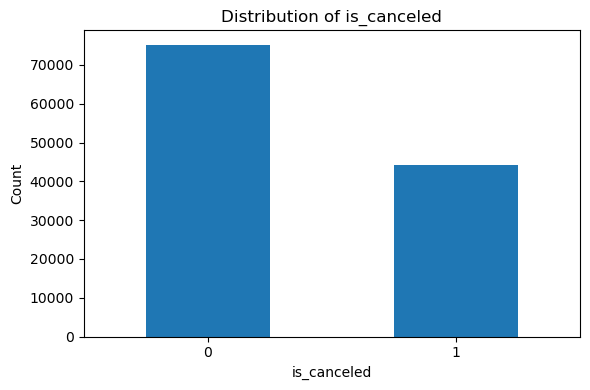

In [3]:
plot_missing(df)
plot_target(df)


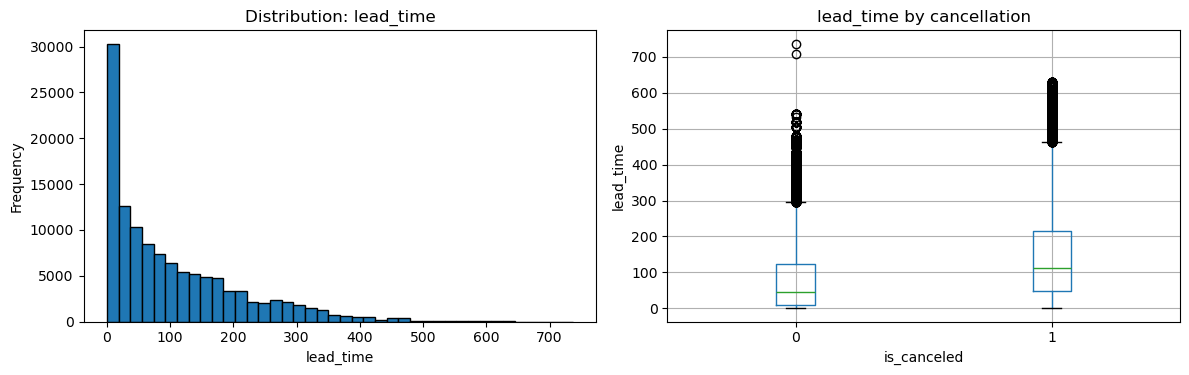

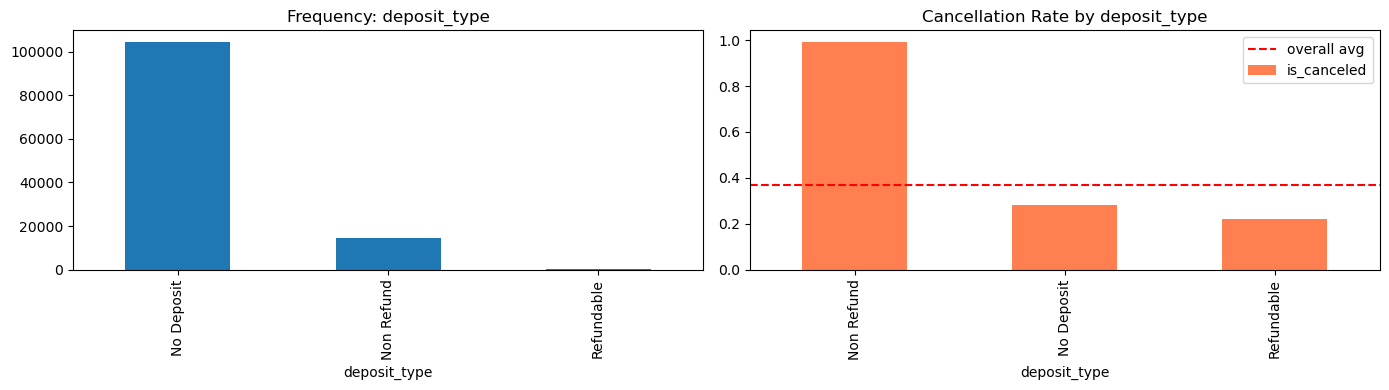

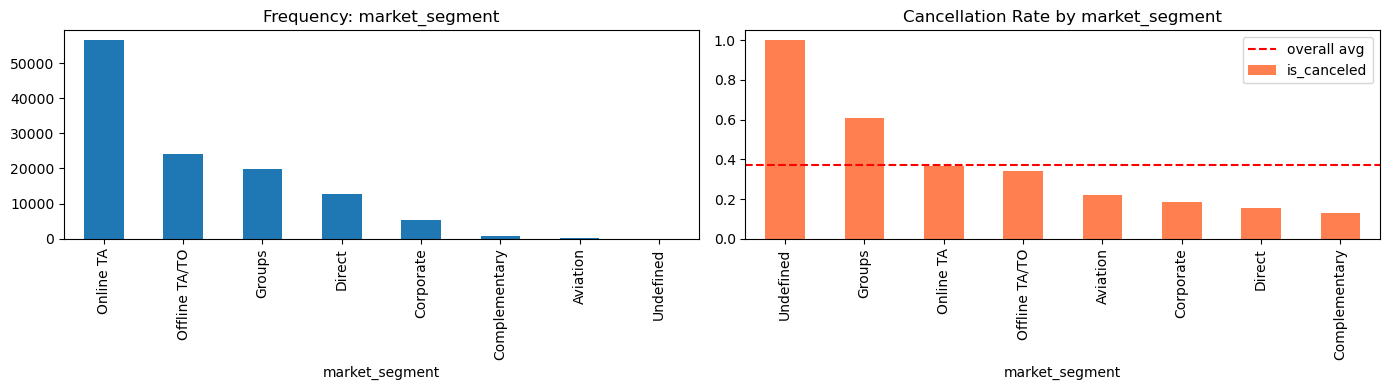

In [4]:
for col in ["lead_time", "deposit_type", "market_segment"]:
    if df[col].dtype == object:
        plot_categorical(df, col)
    else:
        plot_numeric(df, col)


**Insights principais:**

| Variável | Relevância |
|---|---|
| `lead_time` | Feature mais discriminativa — distribuição claramente diferente entre classes |
| `deposit_type` | *Non Refund* com taxa de cancelamento muito acima da média |
| `market_segment` | Segmento *Groups* com risco superior |
| `company` | 94% missing — removida |
| Target | ~63% não cancelado / ~37% cancelado — sem desequilíbrio extremo |


## 4. Preparação dos Dados

- **Duplicados mantidos** — sem identificador único de reserva não é possível confirmar redundância; a remoção alteraria a distribuição da target de 37% para 27%.
- **Leakage removido** — `reservation_status`, `reservation_status_date`, `booking_changes`, `days_in_waiting_list`, `assigned_room_type`.
- **Split temporal** — divisão cronológica via `booking_date = arrival_date − lead_time`: treino até Jun 2016, validação Jul–Dez 2016, teste a partir de 2017.
- **Preprocessing** — `StandardScaler` (numéricas) + `OneHotEncoder` (categóricas), fit exclusivo no treino.


In [5]:
df_dated = reconstruct_booking_date(df)
df_clean = clean_data(df_dated)

train_df, val_df, test_df = split_data(df_clean)

X_train_p, X_val_p, X_test_p, y_train, y_val, y_test, preprocessor = prepare_splits(
    train_df, val_df, test_df
)

X_train_cnn = reshape_for_cnn(X_train_p)
X_val_cnn   = reshape_for_cnn(X_val_p)
X_test_cnn  = reshape_for_cnn(X_test_p)

INPUT_DIM     = X_train_p.shape[1]
INPUT_DIM_CNN = X_train_cnn.shape[1]


Dataset após limpeza: 119,390 observações, 29 colunas.
Missing values restantes: 0
  Train       : 66,253 obs (55.5%)  |  cancel rate: 39.0%  |  2013-06-24 → 2016-06-30
  Validation  : 26,572 obs (22.3%)  |  cancel rate: 37.7%  |  2016-07-01 → 2016-12-31
  Test        : 26,565 obs (22.3%)  |  cancel rate: 31.6%  |  2017-01-01 → 2017-08-31
X_train: (66253, 455)  |  X_val: (26572, 455)  |  X_test: (26565, 455)


## 5. FNN Baseline

Arquitectura mínima — `Dense(1, sigmoid)` — equivalente a uma regressão logística em Keras.  
Serve como referência: qualquer modelo mais complexo tem de superar estes valores para justificar a complexidade adicional.


Model: "fnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │           456 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456 (1.78 KB)

 Trainable params: 456 (1.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8079 - loss: 0.4328 - val_accuracy: 0.7681 - val_loss: 0.4673
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8449 - loss: 0.3407 - val_accuracy: 0.7728 - val_loss: 0.4579
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8482 - loss: 0.3256 - val_accuracy: 0.7731 - val_loss: 0.4549
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8507 - loss: 0.3193 - val_accuracy: 0.7754 - val_loss: 0.4541
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8534 - loss: 0.3160 - val_accuracy: 0.7746 - val_loss: 0.4539
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8546 - loss: 0.3141 - val_accuracy: 0.7751 - val_loss: 0.4535
Epoch 7/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8570 - loss: 0.3128 - val_accuracy: 0.7741 - val_loss: 0.4561
Epoch 8/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8579 - loss: 0.3118 - 

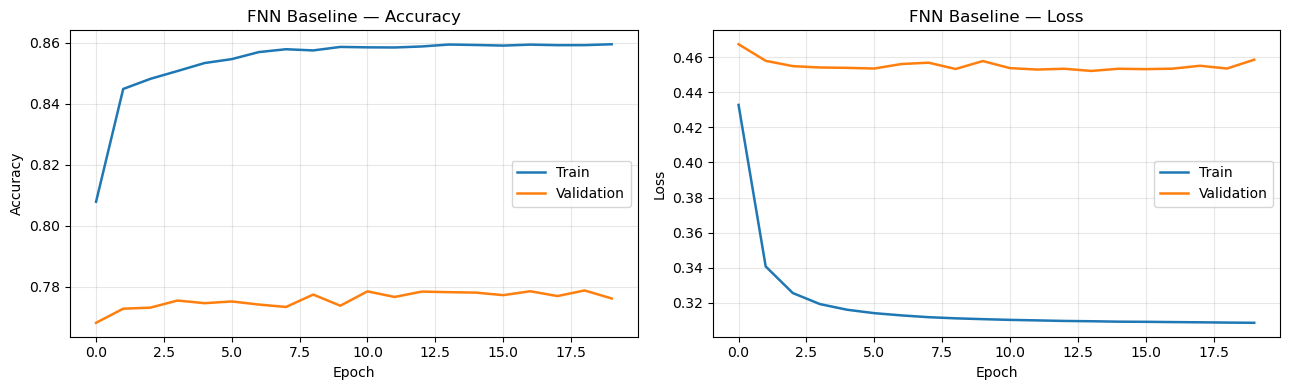

In [6]:
fnn_baseline = build_fnn_baseline(INPUT_DIM)
fnn_baseline.summary()

history_fnn_baseline = train_model_no_early_stop(
    fnn_baseline, X_train_p, y_train, X_val_p, y_val, epochs=20, batch_size=32
)
fnn_baseline_results = evaluate_model(
    fnn_baseline, X_train_p, y_train, X_val_p, y_val, X_test_p, y_test
)
plot_history(history_fnn_baseline, "FNN Baseline")


O baseline atinge ~86% no treino e ~77% em validação e teste — referência estabelecida.  
Arquiteturas mais profundas sem regularização (Dense(64)+Dense(32)) melhoram o treino para ~94%  
mas não generalizam, com `val_loss` crescente: overfitting claro. Isso motiva Dropout + EarlyStopping.


## 6. FNN Final

Para comparação directa com a CNN final, aplica-se a mesma estratégia de regularização à melhor arquitectura FNN:  
`Dense(64) → Dropout(0.5) → Dense(32) → Dropout(0.5) → Dense(1)` com `EarlyStopping(patience=5)`.

Model: "fnn_dropout05"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │        29,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,297 (122.25 KB)

 Trainable params: 31,297 (122.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8491 - loss: 0.3326 - val_accuracy: 0.7886 - val_loss: 0.4324
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8808 - loss: 0.2738 - val_accuracy: 0.7877 - val_loss: 0.4299
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8865 - loss: 0.2601 - val_accuracy: 0.7898 - val_loss: 0.4302
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8912 - loss: 0.2524 - val_accuracy: 0.7938 - val_loss: 0.4294
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8930 - loss: 0.2467 - val_accuracy: 0.7925 - val_loss: 0.4292
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8943 - loss: 0.2425 - val_accuracy: 0.7930 - val_loss: 0.4215
Epoch 7/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8962 - loss: 0.2398 - val_accuracy: 0.7902 - val_loss: 0.4305
Epoch 8/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8979 - loss: 0.2353 - 

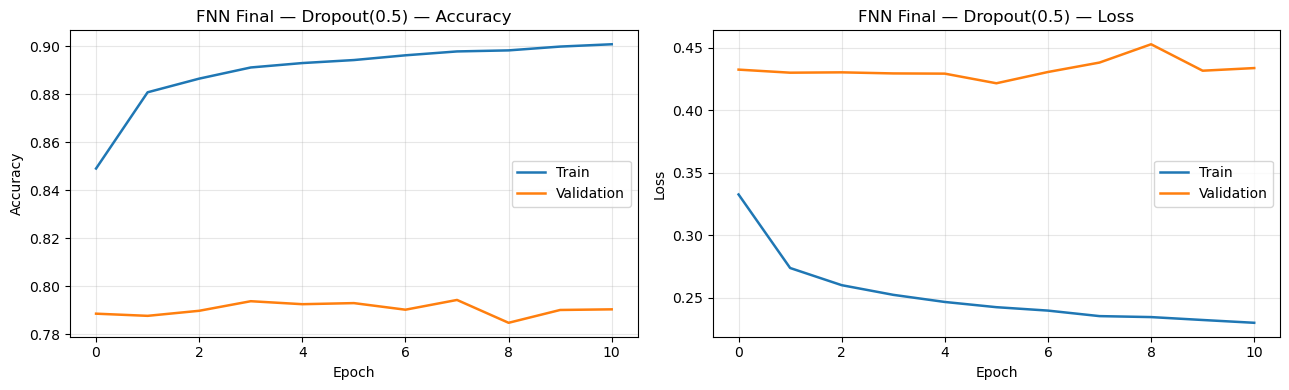

In [13]:
fnn_final = build_fnn_dropout(INPUT_DIM, dropout=0.5)
fnn_final.summary()

history_fnn_final = train_model(
    fnn_final, X_train_p, y_train, X_val_p, y_val,
    epochs=20, batch_size=32, patience=5
)
fnn_final_results = evaluate_model(
    fnn_final, X_train_p, y_train, X_val_p, y_val, X_test_p, y_test
)
plot_history(history_fnn_final, "FNN Final — Dropout(0.5)")

A FNN final atinge ~79% em validação e ~79% em teste — ligeiramente acima da CNN em accuracy global.

## 7. CNN Baseline

Para aplicar `Conv1D` a dados tabulares, a entrada é reformulada de `(n, features)` para `(n, features, 1)`,  
tratando cada observação como uma sequência unidimensional.  
Arquitectura mínima: `Conv1D(32) → MaxPooling1D → Flatten → Dense(1, sigmoid)`.


Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 453, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 226, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7232)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         7,233 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.8369 - loss: 0.3483 - val_accuracy: 0.7625 - val_loss: 0.4713
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8592 - loss: 0.3111 - val_accuracy: 0.7670 - val_loss: 0.4616
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8637 - loss: 0.3043 - val_accuracy: 0.7611 - val_loss: 0.4648
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8655 - loss: 0.2997 - val_accuracy: 0.7608 - val_loss: 0.4689
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8665 - loss: 0.2972 - val_accuracy: 0.7696 - val_loss: 0.4615
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8683 - loss: 0.2946 - val_accuracy: 0.7625 - val_loss: 0.4725
Epoch 7/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8701 - loss: 0.2926 - val_accuracy: 0.7625 - val_loss: 0.4642
Epoch 8/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8698 - loss: 0

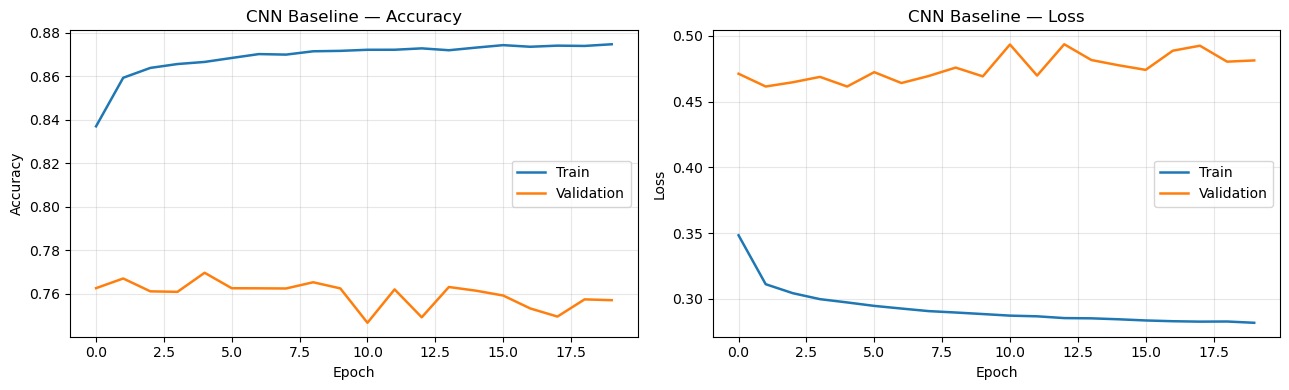

In [7]:
cnn_baseline = build_cnn_baseline(INPUT_DIM_CNN)
cnn_baseline.summary()

history_cnn_baseline = train_model_no_early_stop(
    cnn_baseline, X_train_cnn, y_train, X_val_cnn, y_val, epochs=20, batch_size=32
)
cnn_baseline_results = evaluate_model(
    cnn_baseline, X_train_cnn, y_train, X_val_cnn, y_val, X_test_cnn, y_test
)
plot_history(history_cnn_baseline, "CNN Baseline")


O baseline CNN atinge ~88% no treino e ~76–77% em validação e teste — desempenho logo acima do FNN baseline.  
Confirma que convolution layers conseguem captar padrões relevantes mesmo em dados tabulares, justificando a exploração de arquitecturas mais complexas.


## 8. CNN Final

Arquitectura mais profunda com regularização:  
`Conv1D(32) → Conv1D(64) → MaxPooling1D → Flatten → Dense(32) → Dropout(0.5) → Dense(1)`  
com `EarlyStopping(patience=5)`.

O Dropout controla o overfitting observado no baseline; o EarlyStopping preserva os pesos da melhor época.


Model: "cnn_dropout05"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 453, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 451, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 225, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │       460,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,201 (1.78 MB)

 Trainable params: 467,201 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.8416 - loss: 0.3384 - val_accuracy: 0.7853 - val_loss: 0.4315
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.8644 - loss: 0.2948 - val_accuracy: 0.7866 - val_loss: 0.4415
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.8720 - loss: 0.2816 - val_accuracy: 0.7835 - val_loss: 0.4421
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - accuracy: 0.8729 - loss: 0.2781 - val_accuracy: 0.7785 - val_loss: 0.4415
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.8764 - loss: 0.2702 - val_accuracy: 0.7859 - val_loss: 0.4367
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.8776 - loss: 0.2686 - val_accuracy: 0.7914 - val_loss: 0.4395
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
  Train Accuracy      : 0.8808  (loss: 0.2699)
  Validation Accuracy : 0.7853  (loss: 0.4315)
  Test Accuracy       : 0.7819 

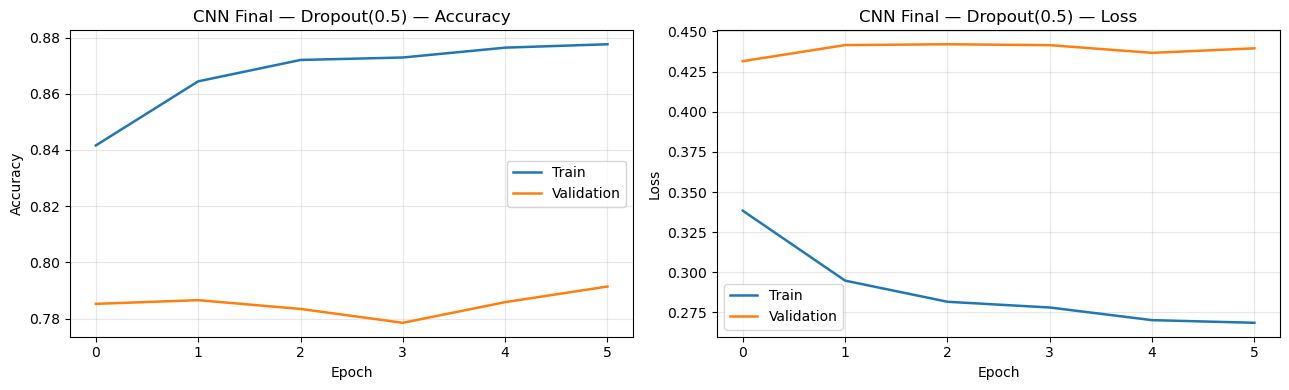

In [8]:
cnn_final = build_cnn_regularized(INPUT_DIM_CNN, dropout=0.5)
cnn_final.summary()

history_cnn_final = train_model(
    cnn_final, X_train_cnn, y_train, X_val_cnn, y_val,
    epochs=20, batch_size=32, patience=5
)
cnn_final_results = evaluate_model(
    cnn_final, X_train_cnn, y_train, X_val_cnn, y_val, X_test_cnn, y_test
)
plot_history(history_cnn_final, "CNN Final — Dropout(0.5)")


A CNN final atinge ~79% em validação e ~78% em teste — melhoria clara face ao baseline CNN.  
As curvas convergem sem degradação da `val_loss`, confirmando que a regularização controlou o overfitting.


## 9. Comparação Final

In [14]:
results = {
    "FNN Baseline":  fnn_baseline_results,
    "FNN Final":     fnn_final_results,
    "CNN Baseline":  cnn_baseline_results,
    "CNN Final ★":   cnn_final_results,
    }
display(compare_models(results))


c:\Projetos\hotel_cancellation_deeplearning\src\evaluate.py:168: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: f"{x:.4f}")


,Train Acc,Val Acc,Test Acc
FNN Baseline,0.8581,0.7761,0.7729
FNN Final,0.9086,0.7930,0.7877
CNN Baseline,0.8769,0.7570,0.7609
CNN Final ★,0.8808,0.7853,0.7819



=== Classification Report — CNN Final ===
                  precision    recall  f1-score   support

Not Canceled (0)       0.83      0.86      0.84     18163
    Canceled (1)       0.67      0.61      0.64      8402

        accuracy                           0.78     26565
       macro avg       0.75      0.73      0.74     26565
    weighted avg       0.78      0.78      0.78     26565



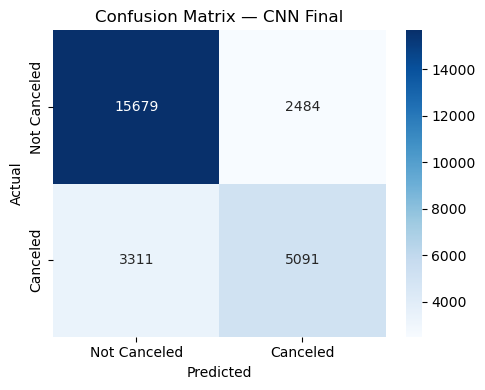


=== Classification Report — FNN Final ===
                  precision    recall  f1-score   support

Not Canceled (0)       0.82      0.88      0.85     18163
    Canceled (1)       0.69      0.59      0.64      8402

        accuracy                           0.79     26565
       macro avg       0.76      0.73      0.74     26565
    weighted avg       0.78      0.79      0.78     26565



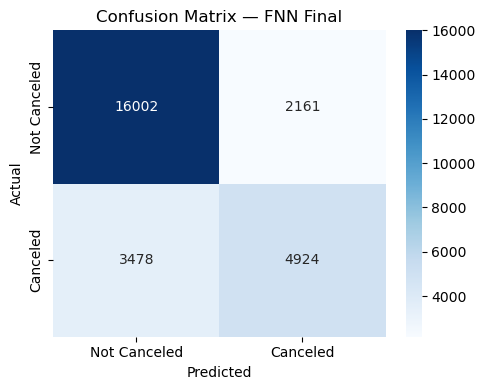

In [15]:
plot_confusion_matrix(cnn_final, X_test_cnn, y_test, title="CNN Final")
plot_confusion_matrix(fnn_final, X_test_p,   y_test, title="FNN Final")


**Leitura dos resultados:**

- Ambos os modelos finais atingem ~79% de accuracy — desempenho equivalente em termos globais.
- A **CNN final** apresenta F1-score ligeiramente superior na classe *Canceled* (1), o que representa melhor equilíbrio entre precision e recall na deteção de cancelamentos — o evento de maior interesse prático.
- A **FNN final** tem accuracy de teste marginalmente superior (~0.2pp), sendo a solução mais natural para dados tabulares independentes.
- Em contexto hoteleiro, os **false negatives** (cancelamentos não detectados) são o erro mais relevante — nesse critério específico, a CNN tem vantagem.


## 10. Conclusão e Utilidade do Modelo

**A CNN acrescentou valor?** Sim, com nuances. Em accuracy global, o resultado é equivalente ao FNN. A vantagem da CNN está na classe de cancelamentos: F1-score marginalmente superior, sugerindo melhor capacidade de sinalizar cancelamentos reais com menor taxa de falsos alarmes. Para um hotel, esta diferença tem relevância prática — um modelo que detecta mais cancelamentos reais permite intervenção antecipada mais eficaz.

**Utilidade prática:**
- Sinalização de reservas com maior risco de cancelamento no momento da criação
- Apoio à gestão de ocupação e decisões de overbooking
- Complemento quantitativo à análise operacional

**Limitações:**
- Threshold de 0.5 não optimizado para o custo real dos dois tipos de erro
- Dataset específico de dois hotéis num período limitado — generalização requer validação externa

**Trabalho futuro:** ajuste de threshold, embeddings para variáveis categóricas (country, agent), explicabilidade via SHAP.


In [16]:
# Exemplo de previsão — reserva com perfil de risco elevado
new_booking = pd.DataFrame([{
    "hotel": "City Hotel", "lead_time": 300,
    "arrival_date_year": 2017, "arrival_date_month": "August",
    "arrival_date_week_number": 35, "arrival_date_day_of_month": 25,
    "stays_in_weekend_nights": 1, "stays_in_week_nights": 3,
    "adults": 2, "children": 0, "babies": 0, "meal": "BB",
    "country": "PRT", "market_segment": "Online TA",
    "distribution_channel": "TA/TO", "is_repeated_guest": 0,
    "previous_cancellations": 5, "previous_bookings_not_canceled": 0,
    "reserved_room_type": "A", "deposit_type": "Non Refund",
    "agent": "9.0", "customer_type": "Transient",
    "adr": 180.0, "required_car_parking_spaces": 0,
    "total_of_special_requests": 0
}])

for col in CATEGORICAL_COLS:
    new_booking[col] = new_booking[col].astype(str)

new_p = preprocessor.transform(new_booking).toarray()

# Previsão com CNN Final
pred_cnn = cnn_final.predict(reshape_for_cnn(new_p), verbose=0)[0][0]
pred_fnn = fnn_final.predict(new_p, verbose=0)[0][0]

print(f"CNN Final — P(cancelamento): {pred_cnn:.4f} → {'Cancelado' if pred_cnn >= 0.5 else 'Não cancelado'}")
print(f"FNN Final — P(cancelamento): {pred_fnn:.4f} → {'Cancelado' if pred_fnn >= 0.5 else 'Não cancelado'}")


CNN Final — P(cancelamento): 1.0000 → Cancelado
FNN Final — P(cancelamento): 1.0000 → Cancelado
